# Classificação Supervisionada com KMeans no Dataset Adult (Balanceado)

Este notebook aplica o balanceamento das classes do dataset Adult por oversampling da classe minoritária antes do treinamento do KMeans supervisionado. O objetivo é comparar o desempenho do agrupamento com e sem desbalanceamento.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.cluster import KMeans
import os
import seaborn as sns
from sklearn.decomposition import PCA

img_dir = 'img'
os.makedirs(img_dir, exist_ok=True)

## 1. Carregamento e Balanceamento dos Dados

In [14]:
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)
adult_df = adult_df_raw.dropna().copy()
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=n_majority,
    random_state=42
)
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


## 2. Pré-processamento dos Dados

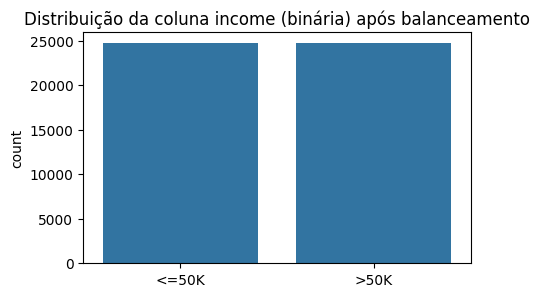

In [15]:
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
y = adult_df_balanced['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária) após balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [17]:
n_clusters = 10

In [18]:
class KMeansSupervisionado:
    def __init__(self, n_clusters=n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

Acurácia: 0.7060
Matriz de Confusão:
[[4982 2434]
 [1927 5489]]


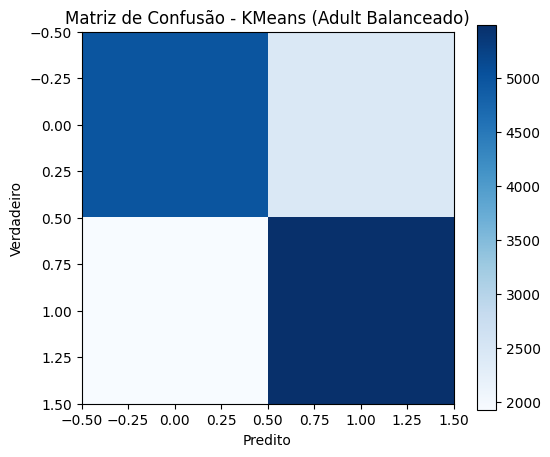

In [19]:
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=30)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - KMeans (Adult Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig(f'{img_dir}/kmeans_adult_balance_confusion_matrix.png')
plt.show()

## Visualização dos Agrupamentos com PCA

Para visualizar os agrupamentos do KMeans em 2D, utilizamos o PCA (Análise de Componentes Principais), que reduz a dimensionalidade dos dados mantendo a maior variância possível. Assim, é possível observar a separação dos clusters e a posição dos centros no espaço reduzido.

Acurácia: 0.7060
Matriz de Confusão:
[[4982 2434]
 [1927 5489]]


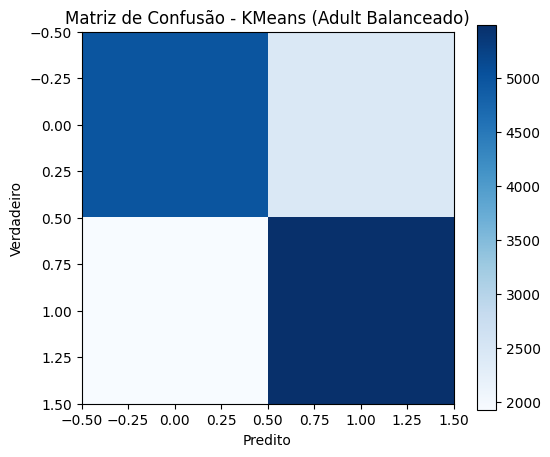

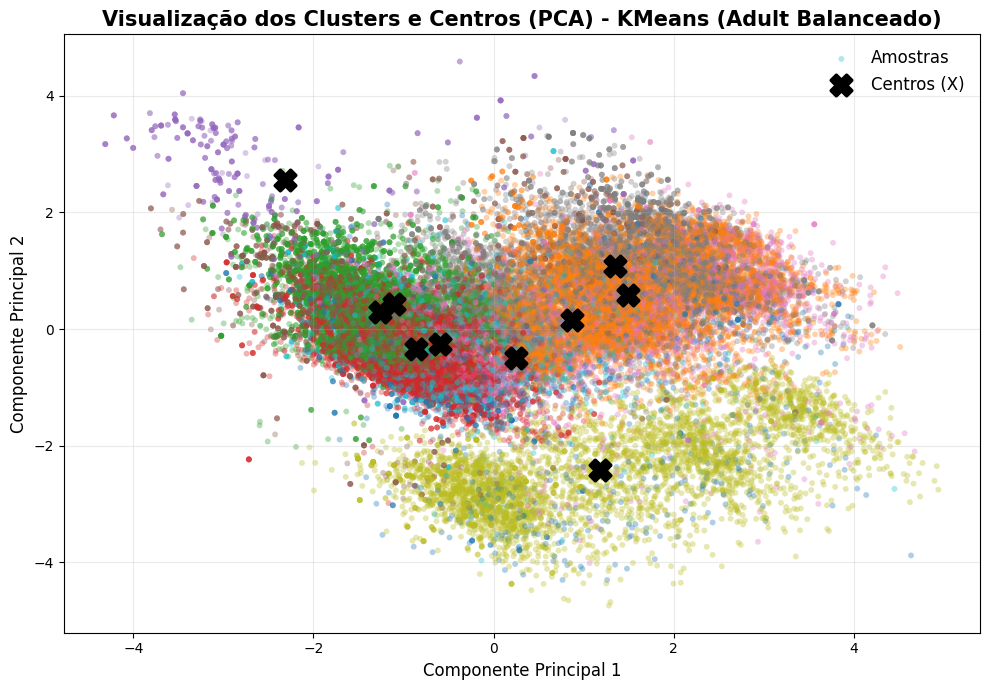

In [20]:
# Redução de dimensionalidade para 2D com PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Ajusta o KMeans nos dados completos para obter os clusters e centros
cls = KMeans(n_clusters=n_clusters, random_state=42)
clusters = cls.fit_predict(X)
centros = cls.cluster_centers_
centros_pca = pca.transform(centros)
acc, cm = clf.evaluate(X_test, y_test)

print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - KMeans (Adult Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig(f'{img_dir}/kmeans_adult_balance_confusion_matrix.png')
plt.show()


plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
)
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
)
plt.title('Visualização dos Clusters e Centros (PCA) - KMeans (Adult Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_clusters_pca.png'), dpi=150)
plt.show()

Acurácia média: 0.7176
Desvio padrão da acurácia: 0.0142
MSE médio: 0.2824
Desvio padrão do MSE: 0.0142

Matriz de Confusão Média (30 execuções):
[[4877 2539]
 [1650 5766]]


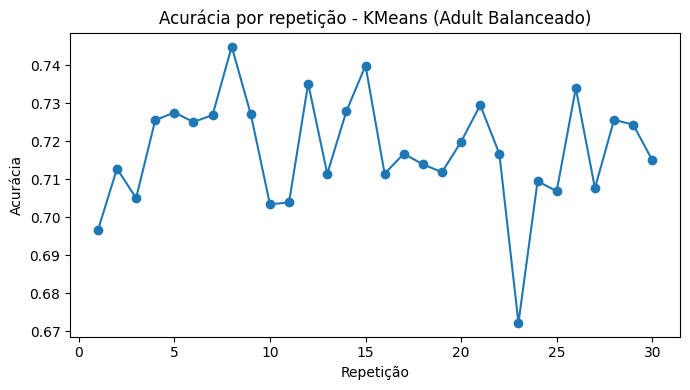

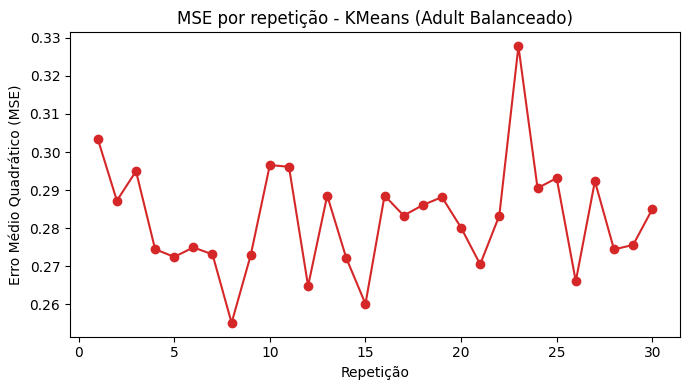

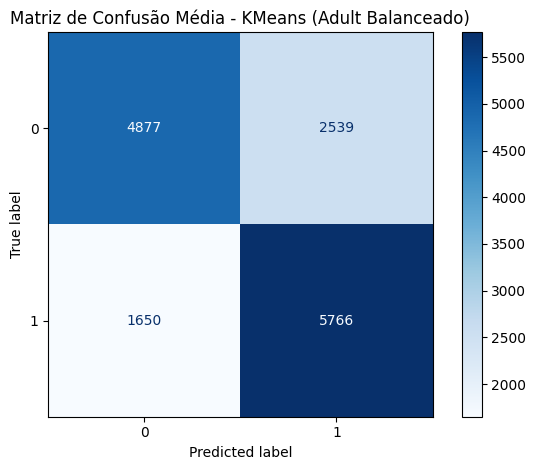

Acurácia: 0.7176
Precisão: 0.6943
Revocação (Recall): 0.7775
Especificidade: 0.6576
F1-Score: 0.7335
TN: 4877, FP: 2539, FN: 1650, TP: 5766


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

acuracias = []
mse_list = []
matrizes_confusao = []

for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred))

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
matrizes_confusao = np.array(matrizes_confusao)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_int = np.round(matriz_confusao_media).astype(int)

print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print('\nMatriz de Confusão Média (30 execuções):')
print(matriz_confusao_media_int)

plt.figure(figsize=(7,4))
plt.plot(range(1, 31), acuracias, marker='o', color='tab:blue')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_accuracy_repetitions.png'))
plt.show()

plt.figure(figsize=(7,4))
plt.plot(range(1, 31), mse_array, marker='o', color='tab:red')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_mse_repetitions.png'))
plt.show()

# Exibe a matriz de confusão média graficamente
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_media_int)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media.png'))
plt.show()

# Salva os resultados
np.save(os.path.join(img_dir, 'kmeans_adult_balance_accuracies.npy'), acuracias)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_accuracies.csv'), acuracias, delimiter=',')
np.save(os.path.join(img_dir, 'kmeans_adult_balance_mse_repetitions.npy'), mse_array)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_mse_repetitions.csv'), mse_array, delimiter=',')
np.save(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media.npy'), matriz_confusao_media)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media.csv'), matriz_confusao_media, delimiter=',')

# Métricas comuns da matriz de confusão
if matriz_confusao_media_int.shape == (2, 2):
    TN, FP, FN, TP = matriz_confusao_media_int[0,0], matriz_confusao_media_int[0,1], matriz_confusao_media_int[1,0], matriz_confusao_media_int[1,1]
    total = TN + FP + FN + TP
    acuracia = (TP + TN) / total if total > 0 else 0
    precisao = TP / (TP + FP) if (TP + FP) > 0 else 0
    revocacao = TP / (TP + FN) if (TP + FN) > 0 else 0
    especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1 = 2 * (precisao * revocacao) / (precisao + revocacao) if (precisao + revocacao) > 0 else 0

    print(f'Acurácia: {acuracia:.4f}')
    print(f'Precisão: {precisao:.4f}')
    print(f'Revocação (Recall): {revocacao:.4f}')
    print(f'Especificidade: {especificidade:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}')
else:
    print("A matriz de confusão média não é 2x2. Não é possível calcular as métricas binárias.")



**Como funciona o PCA:**

O PCA encontra as direções (componentes principais) que mais explicam a variância dos dados. Os dados são projetados nesses novos eixos, permitindo reduzir de dezenas de dimensões para 2, facilitando a visualização dos agrupamentos. No gráfico acima, cada ponto representa uma amostra projetada no novo espaço 2D, colorida conforme o cluster atribuído pelo KMeans. Os marcadores vermelhos (X) indicam os centros dos clusters nesse espaço reduzido.

## Análise dos Resultados

Compare os resultados obtidos com o dataset balanceado e o original. Observe se houve melhora na matriz de confusão, acurácia média e estabilidade do método.


Análise para n_clusters = 2
Acurácia média: 0.6701
Desvio padrão da acurácia: 0.0524
MSE médio: 0.3299
Desvio padrão do MSE: 0.0524
Acurácia média: 0.6701
Desvio padrão da acurácia: 0.0524
MSE médio: 0.3299
Desvio padrão do MSE: 0.0524


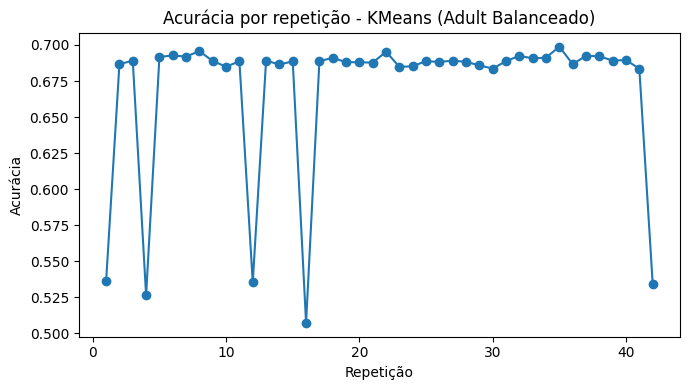

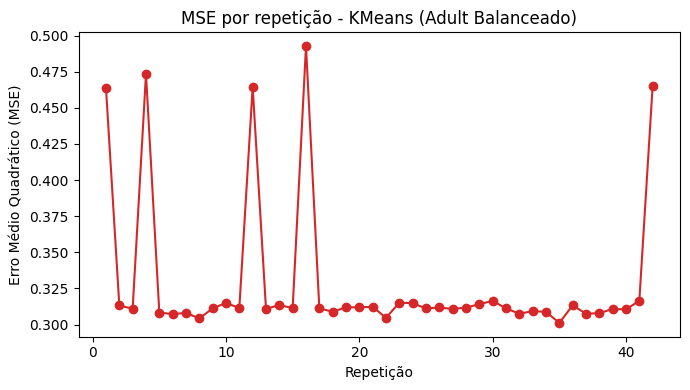


Análise para n_clusters = 3
Acurácia média: 0.6806
Desvio padrão da acurácia: 0.0334
MSE médio: 0.3194
Desvio padrão do MSE: 0.0334
Acurácia média: 0.6806
Desvio padrão da acurácia: 0.0334
MSE médio: 0.3194
Desvio padrão do MSE: 0.0334


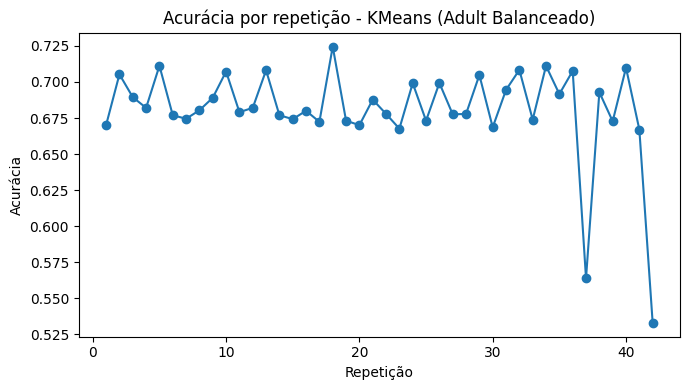

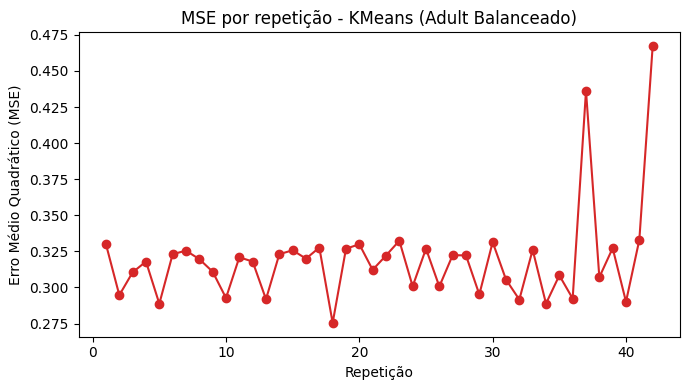


Análise para n_clusters = 4
Acurácia média: 0.6959
Desvio padrão da acurácia: 0.0239
MSE médio: 0.3041
Desvio padrão do MSE: 0.0239
Acurácia média: 0.6959
Desvio padrão da acurácia: 0.0239
MSE médio: 0.3041
Desvio padrão do MSE: 0.0239


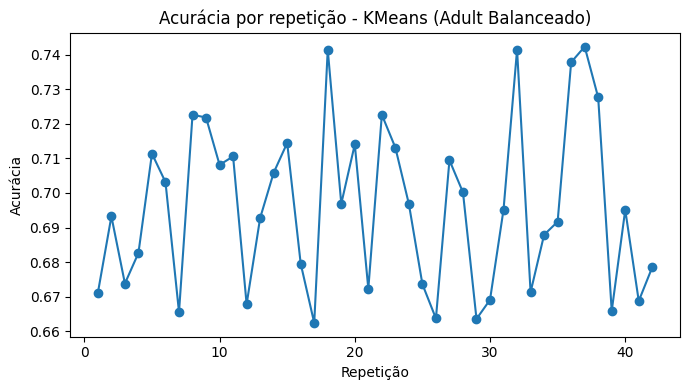

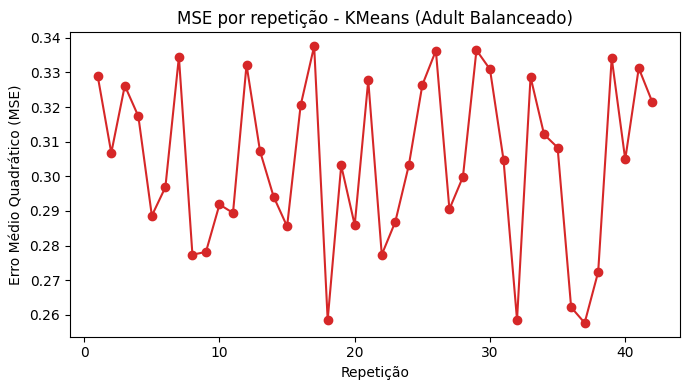


Análise para n_clusters = 5
Acurácia média: 0.7036
Desvio padrão da acurácia: 0.0249
MSE médio: 0.2964
Desvio padrão do MSE: 0.0249
Acurácia média: 0.7036
Desvio padrão da acurácia: 0.0249
MSE médio: 0.2964
Desvio padrão do MSE: 0.0249


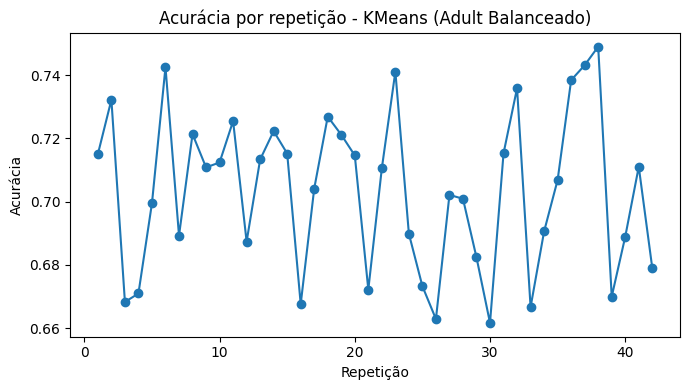

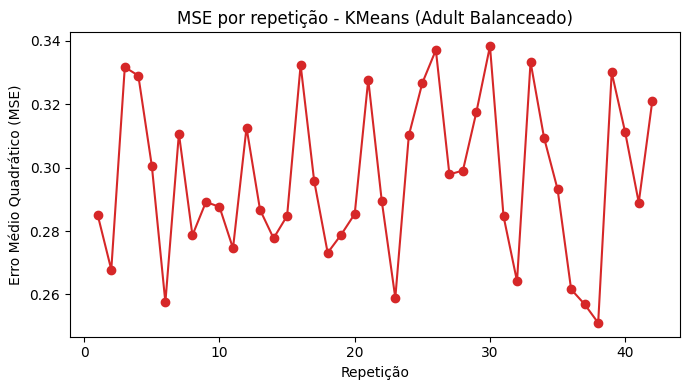


Análise para n_clusters = 6
Acurácia média: 0.7064
Desvio padrão da acurácia: 0.0221
MSE médio: 0.2936
Desvio padrão do MSE: 0.0221
Acurácia média: 0.7064
Desvio padrão da acurácia: 0.0221
MSE médio: 0.2936
Desvio padrão do MSE: 0.0221


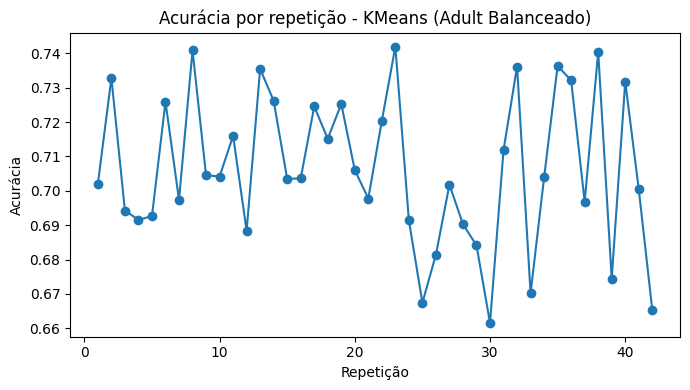

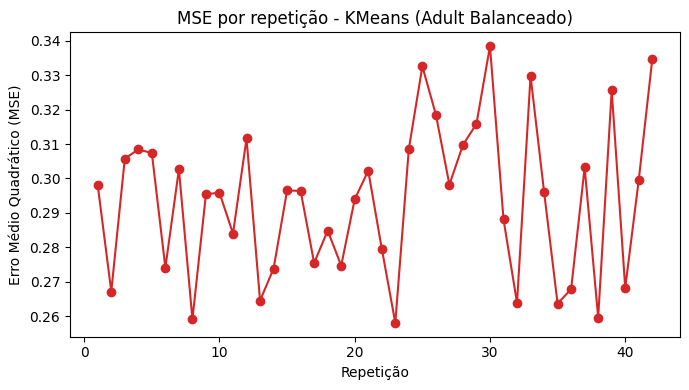


Análise para n_clusters = 7
Acurácia média: 0.7126
Desvio padrão da acurácia: 0.0189
MSE médio: 0.2874
Desvio padrão do MSE: 0.0189
Acurácia média: 0.7126
Desvio padrão da acurácia: 0.0189
MSE médio: 0.2874
Desvio padrão do MSE: 0.0189


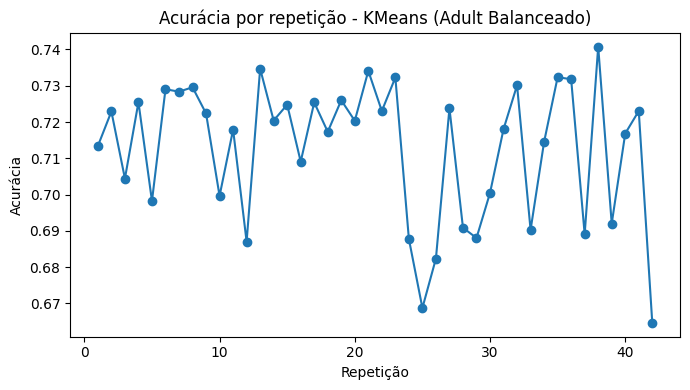

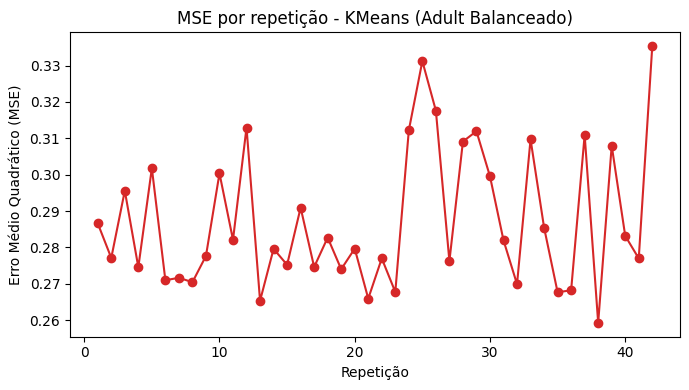


Análise para n_clusters = 8


In [ ]:
clusters = 30 # Ajuste conforme o método do cotovelo
seeds = 42  # Semente para reprodutibilidade
for n_clusters in range(2, clusters + 1):
    print(f'\nAnálise para n_clusters = {n_clusters}')
    # Reinicializa as listas de acurácia e MSE para cada n_clusters
    acuracias = []
    mse_list = []

    for seed in range(1, seeds + 1):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=seed, stratify=y)
        clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        acuracias.append(acc)
        mse_list.append(mse)
    acuracias = np.array(acuracias)
    mse_array = np.array(mse_list)
    print(f'Acurácia média: {acuracias.mean():.4f}')
    print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
    print(f'MSE médio: {mse_array.mean():.4f}')
    print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
    plt.figure(figsize=(7,4))
    plt.plot(range(1, seeds+1), acuracias, marker='o', color='tab:blue')
    plt.xlabel('Repetição')
    plt.ylabel('Acurácia')
    plt.title('Acurácia por repetição - KMeans (Adult Balanceado)')
    plt.tight_layout()
    plt.savefig('img/kmeans_adult_balance_accuracy_repetitions.png')
    plt.show()
    plt.figure(figsize=(7,4))
    plt.plot(range(1, seeds+1), mse_array, marker='o', color='tab:red')
    plt.xlabel('Repetição')
    plt.ylabel('Erro Médio Quadrático (MSE)')
    plt.title('MSE por repetição - KMeans (Adult Balanceado)')
    plt.tight_layout()
    plt.savefig('img/kmeans_adult_balance_mse_repetitions.png')
    plt.show()
    np.save('img/kmeans_adult_balance_accuracies.npy', acuracias)
    np.savetxt('img/kmeans_adult_balance_accuracies.csv', acuracias, delimiter=',')
    np.save('img/kmeans_adult_balance_mse_repetitions.npy', mse_array)
    np.savetxt('img/kmeans_adult_balance_mse_repetitions.csv', mse_array, delimiter=',')

Verdadeiro Negativo (TN):
Quantidade de exemplos negativos corretamente classificados como negativos.
Exemplo: Pessoas que realmente ganham <=50K e foram classificadas como <=50K.

Falso Positivo (FP):
Quantidade de exemplos negativos classificados incorretamente como positivos.
Exemplo: Pessoas que ganham <=50K, mas foram classificadas como >50K (falso alarme).

Falso Negativo (FN):
Quantidade de exemplos positivos classificados incorretamente como negativos.
Exemplo: Pessoas que ganham >50K, mas foram classificadas como <=50K (erro de omissão).

Verdadeiro Positivo (TP):
Quantidade de exemplos positivos corretamente classificados como positivos.
Exemplo: Pessoas que realmente ganham >50K e foram classificadas como >50K.

Acurácia:
Proporção de acertos (positivos e negativos) sobre o total de exemplos.
Fórmula: (TP + TN) / (TP + TN + FP + FN)
Traduz a taxa geral de acerto do modelo.

Precisão (Precision):
Proporção de positivos previstos que realmente são positivos.
Fórmula: TP / (TP + FP)
Traduz o quanto o modelo é confiável quando prevê a classe positiva.

Revocação (Recall) ou Sensibilidade:
Proporção de positivos reais que foram corretamente identificados.
Fórmula: TP / (TP + FN)
Traduz a capacidade do modelo de encontrar todos os positivos.

Especificidade:
Proporção de negativos reais corretamente identificados.
Fórmula: TN / (TN + FP)
Traduz a capacidade do modelo de identificar corretamente os negativos.

F1-Score:
Média harmônica entre precisão e revocação.
Fórmula: 2 * (Precisão * Revocação) / (Precisão + Revocação)
Traduz o equilíbrio entre precisão e revocação, útil quando há desbalanceamento.

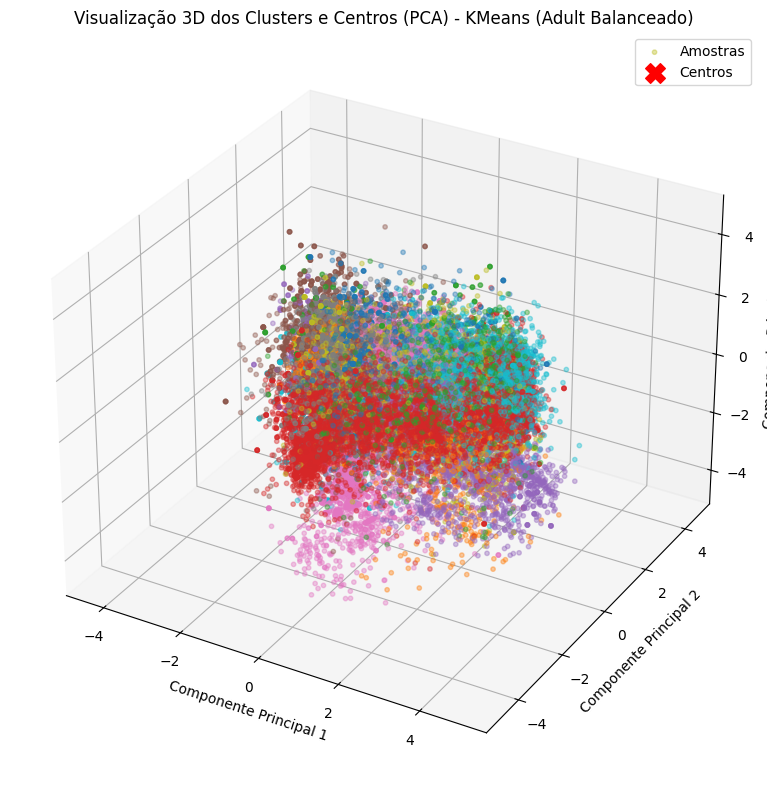

In [ ]:


from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Amostras
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=clusters, cmap='tab10', alpha=0.4, s=10, label='Amostras')
# Centros
ax.scatter(centros_pca[:,0], centros_pca[:,1], centros_pca[:,2], c='red', marker='X', s=200, label='Centros')

ax.set_title('Visualização 3D dos Clusters e Centros (PCA) - KMeans (Adult Balanceado)')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_clusters_pca_3d.png'))
plt.show()
